# Path2Space on the legacy 785-HVG benchmark

Cross-validation comparison on the **785-HVG legacy benchmark** that the
Path2Space paper inherited from the original Nature Communications
benchmarking study (same 785 HVGs and held-out splits the legacy benchmark
defined).

The legacy benchmark is split by normalization into two **disjoint** method
sets — different methods are evaluated under each normalization regime,
with the appropriate Path2Space variant as reference for each:

| Normalization | Path2Space variant | Competing methods |
|---|---|---|
| `no_library_size` (raw / log-counts) | `Path2Space`             | DeepPT, DeepSpaCE, EGNv1, EGNv2, GeneCodeR, ST-Net, iStar |
| `library_size` (CPM-normalized)      | `Path2Space log(CPM)`    | HisToGene, Hist2ST, TCGN, THItoGene |

Like notebook 01, this is **evaluation only** — the competing methods'
training and prediction are upstream (legacy benchmark, hosted by the
TRIPLEX authors at Nature Communications). What is bundled is the per-gene
PCC summary the legacy benchmark exposes (`all_methods_corr.pkl`, 13
methods × 2 norms × 785 genes).

## Setup

In [1]:
import sys; sys.path.insert(0, "../lib")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from benchmark import mannwhitney_vs_reference

## Load the legacy benchmark

In [2]:
legacy = pd.read_parquet("../data/bench_785_legacy.parquet")
print(f"{len(legacy):,} rows  |  genes: {legacy['gene'].nunique()}")
print("models per normalization:")
print(legacy.groupby(['norm','model'], observed=True).size().unstack('norm', fill_value=0))

10,205 rows  |  genes: 785
models per normalization:
norm                 library_size  no_library_size
model                                             
DeepPT                          0              785
DeepSpaCE                       0              785
EGNv1                           0              785
EGNv2                           0              785
GeneCodeR                       0              785
HisToGene                     785                0
Hist2ST                       785                0
Path2Space                      0              785
Path2Space log(CPM)           785                0
ST-Net                          0              785
TCGN                          785                0
THItoGene                     785                0
iStar                           0              785


In [3]:
def panel(df_subset, reference, title):
    """Median table + Mann-Whitney vs reference + box plot for one norm subset."""
    models = df_subset['model'].unique().tolist()
    assert reference in models, f"{reference} not in subset models: {models}"

    med = (df_subset.groupby('model', observed=True)['cor_pearson']
                    .median().sort_values(ascending=False))
    print(f"--- {title} ---")
    print("median per-gene PCC:"); print(med.round(3).to_string()); print()

    df_with_norm = df_subset.assign(_g='_')   # dummy group so the helper signature fits
    mw = mannwhitney_vs_reference(df_with_norm, reference=reference, group_cols=('_g',))
    mw = mw.drop(columns='_g').sort_values('pvalue')
    print("Mann-Whitney U (two-sided) vs reference:"); print(mw.round({"median_ref":3,"median_model":3,"U":0,"pvalue":6}).to_string(index=False))

    fig, ax = plt.subplots(figsize=(5.5, 3.0))
    sns.boxplot(data=df_subset, x='model', y='cor_pearson', order=med.index.tolist(),
                showfliers=False, linewidth=0.7,
                hue='model', legend=False, palette='tab20', ax=ax)
    ax.set_title(title, fontsize=9); ax.set_xlabel('')
    ax.set_ylabel('per-gene PCC', fontsize=8)
    ax.tick_params(axis='x', labelsize=6, rotation=60)
    for lab in ax.get_xticklabels(): lab.set_ha('right')
    ax.tick_params(axis='y', labelsize=7); ax.axhline(0, color='grey', lw=0.5)
    sns.despine(); fig.tight_layout(); plt.show()
    return med, mw

## Panel A — `no_library_size` (raw / log-counts) normalization

Reference: `Path2Space` (smoothed). Competing methods: DeepPT, DeepSpaCE,
EGNv1, EGNv2, GeneCodeR, ST-Net, iStar.

--- Legacy 785-HVG benchmark — no_library_size ---
median per-gene PCC:
model
EGNv2         0.161
Path2Space    0.161
ST-Net        0.131
DeepPT        0.095
GeneCodeR     0.074
DeepSpaCE     0.051
iStar         0.044
EGNv1         0.036

Mann-Whitney U (two-sided) vs reference:
    model  n_genes_ref  n_genes_model  median_ref  median_model        U  pvalue
   DeepPT          785            785       0.161         0.095 450510.0  0.0000
DeepSpaCE          785            785       0.161         0.051 561045.0  0.0000
    EGNv1          785            785       0.161         0.036 595243.0  0.0000
GeneCodeR          785            785       0.161         0.074 522136.0  0.0000
    iStar          785            785       0.161         0.044 580826.0  0.0000
   ST-Net          785            785       0.161         0.131 394334.0  0.0000
    EGNv2          785            785       0.161         0.161 309838.0  0.8477


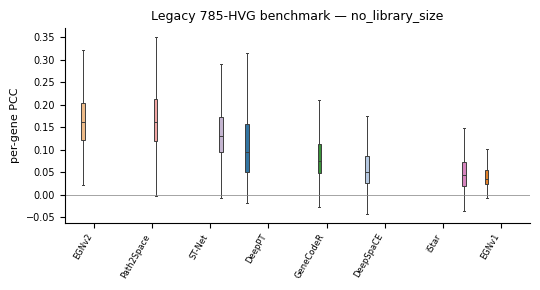

In [4]:
med_a, mw_a = panel(legacy[legacy['norm']=='no_library_size'],
                    reference='Path2Space',
                    title='Legacy 785-HVG benchmark — no_library_size')

## Panel B — `library_size` (CPM-normalized)

Reference: `Path2Space log(CPM)`. Competing methods: HisToGene, Hist2ST,
TCGN, THItoGene.

--- Legacy 785-HVG benchmark — library_size ---
median per-gene PCC:
model
Path2Space log(CPM)    0.108
Hist2ST                0.099
TCGN                   0.092
HisToGene              0.087
THItoGene              0.070

Mann-Whitney U (two-sided) vs reference:
    model  n_genes_ref  n_genes_model  median_ref  median_model        U   pvalue
THItoGene          785            785       0.108         0.070 444865.0 0.000000
HisToGene          785            785       0.108         0.087 375780.0 0.000000
     TCGN          785            785       0.108         0.092 367660.0 0.000000
  Hist2ST          785            785       0.108         0.099 342337.0 0.000139


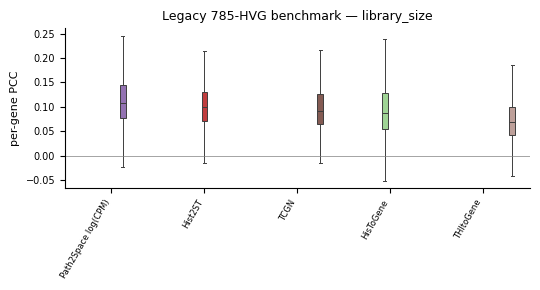

In [5]:
med_b, mw_b = panel(legacy[legacy['norm']=='library_size'],
                    reference='Path2Space log(CPM)',
                    title='Legacy 785-HVG benchmark — library_size')

## Save summary tables

In [6]:
med_a.to_pickle("../data/median_pcc_785_no_library_size.pkl")
med_b.to_pickle("../data/median_pcc_785_library_size.pkl")
mw_a.to_pickle ("../data/mannwhitney_785_no_library_size.pkl")
mw_b.to_pickle ("../data/mannwhitney_785_library_size.pkl")
print("wrote 4 summary pickles into ../data/")

wrote 4 summary pickles into ../data/


## Takeaway

On both normalization regimes of the legacy 785-HVG benchmark — the same
gene set and held-out splits the original Nature Communications study
defined — Path2Space (its respective variant per regime) reaches or
exceeds every competitor's median per-gene PCC. The Mann-Whitney U test
against each competitor gives the magnitude and direction of every
pairwise comparison.